# Demographic EDA: Contact Dataset

This notebook explores the demographic characteristics of the developer contact dataset using DuckDB.

Sections covered:
- Environment setup
- Dataset overview
- Geographic distribution (country, region, sub-region, zone, territory)
- Industry & vertical segmentation
- Development areas & fields of interest
- Account profile (type, source, industry)
- Program enrollment & engagement over time
- WWFO segmentation
- Missingness audit

## 1. Environment Setup

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── connection ──────────────────────────────────────────────────────────────
DB_PATH = "developer_project.duckdb"
con = duckdb.connect(DB_PATH)

# ── display settings ────────────────────────────────────────────────────────
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

# ── plot style ───────────────────────────────────────────────────────────────
NVIDIA_GREEN  = "#76b900"
NVIDIA_DARK   = "#1a1a1a"
PALETTE       = ["#76b900", "#00a3e0", "#f5a623", "#e03c31",
                 "#9b59b6", "#1abc9c", "#e67e22", "#2c3e50"]

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#f8f8f8",
    "axes.edgecolor":    "#cccccc",
    "axes.grid":         True,
    "grid.color":        "#e0e0e0",
    "grid.linestyle":    "--",
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "font.family":       "sans-serif",
})

# ── reusable helper ──────────────────────────────────────────────────────────
CONTACT_TABLE = "contact_clean"   # swap to contact_final if available

def q(sql, **kwargs):
    """Run a DuckDB query, return a DataFrame."""
    return con.execute(sql.format(**kwargs)).fetchdf()

def show(title, sql, limit=None, **kwargs):
    """Print a titled DataFrame."""
    full = sql if limit is None else f"{sql}\nLIMIT {limit}"
    df = q(full, **kwargs)
    print(f"\n{'─'*60}")
    print(f"  {title}")
    print(f"{'─'*60}")
    display(df)
    return df

print("Setup complete. Tables available:")
display(q("SHOW TABLES"))

Setup complete. Tables available:


,name
0,activity_base
1,activity_base_v2
2,activity_clean
3,activity_dictionary_v2
4,activity_effort_mapping_ai_v2
5,activity_final
6,activity_labeled_v2
7,activity_raw
8,activity_sample
9,activity_score_mapping_clean


## 2. Dataset Overview

In [2]:
# ── schema ───────────────────────────────────────────────────────────────────
show("Contact table schema", f"DESCRIBE {CONTACT_TABLE}")


────────────────────────────────────────────────────────────
  Contact table schema
────────────────────────────────────────────────────────────


,column_name,column_type,null,key,default,extra
0,developer_id,VARCHAR,YES,None,None,None
1,program_application_source,VARCHAR,YES,None,None,None
2,country,VARCHAR,YES,None,None,None
3,region,VARCHAR,YES,None,None,None
4,sub_region,VARCHAR,YES,None,None,None
5,zone,VARCHAR,YES,None,None,None
6,territory,VARCHAR,YES,None,None,None
7,organization_english_name,VARCHAR,YES,None,None,None
8,development_areas,VARCHAR,YES,None,None,None
9,other_development_areas,VARCHAR,YES,None,None,None


,column_name,column_type,null,key,default,extra
0,developer_id,VARCHAR,YES,None,None,None
1,program_application_source,VARCHAR,YES,None,None,None
2,country,VARCHAR,YES,None,None,None
3,region,VARCHAR,YES,None,None,None
4,sub_region,VARCHAR,YES,None,None,None
5,zone,VARCHAR,YES,None,None,None
6,territory,VARCHAR,YES,None,None,None
7,organization_english_name,VARCHAR,YES,None,None,None
8,development_areas,VARCHAR,YES,None,None,None
9,other_development_areas,VARCHAR,YES,None,None,None


In [3]:
# ── high-level counts ────────────────────────────────────────────────────────
show("High-level row and developer counts", f"""
SELECT
    COUNT(*)                                          AS total_rows,
    COUNT(DISTINCT developer_id)                      AS unique_developers,
    COUNT(DISTINCT country)                           AS unique_countries,
    COUNT(DISTINCT region)                            AS unique_regions,
    COUNT(DISTINCT industry_segment_vertical)         AS unique_industry_segments,
    COUNT(DISTINCT account_type)                      AS unique_account_types,
    MIN(created_date)::DATE                           AS earliest_created,
    MAX(created_date)::DATE                           AS latest_created
FROM {CONTACT_TABLE}
""", CONTACT_TABLE=CONTACT_TABLE)


────────────────────────────────────────────────────────────
  High-level row and developer counts
────────────────────────────────────────────────────────────


,total_rows,unique_developers,unique_countries,unique_regions,unique_industry_segments,unique_account_types,earliest_created,latest_created
0,9381490,9381490,250,4,21,6,2013-04-12,2026-03-13


,total_rows,unique_developers,unique_countries,unique_regions,unique_industry_segments,unique_account_types,earliest_created,latest_created
0,9381490,9381490,250,4,21,6,2013-04-12,2026-03-13


## 3. Geographic Distribution

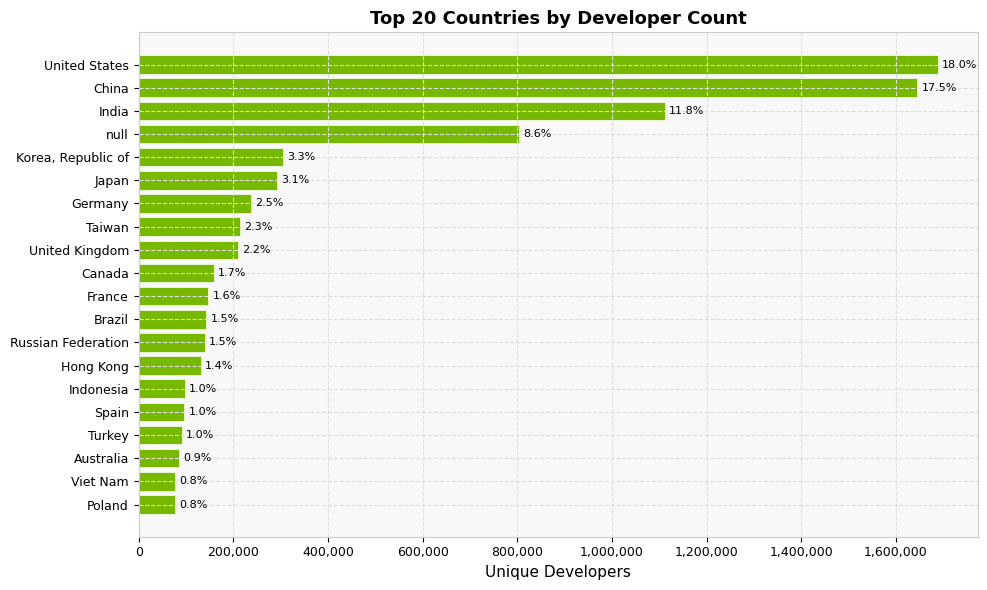

,country,developers,pct
0,United States,1688338,18.00
1,China,1645122,17.54
2,India,1111879,11.85
3,null,804111,8.57
4,"Korea, Republic of",305752,3.26
5,Japan,292502,3.12
6,Germany,238016,2.54
7,Taiwan,213672,2.28
8,United Kingdom,209229,2.23
9,Canada,159076,1.70


In [4]:
# ── top 20 countries ─────────────────────────────────────────────────────────
top_countries = q(f"""
SELECT
    COALESCE(NULLIF(TRIM(country), ''), 'Unknown') AS country,
    COUNT(DISTINCT developer_id) AS developers,
    ROUND(100.0 * COUNT(DISTINCT developer_id)
          / SUM(COUNT(DISTINCT developer_id)) OVER (), 2) AS pct
FROM {CONTACT_TABLE}
GROUP BY 1
ORDER BY developers DESC
LIMIT 20
""", CONTACT_TABLE=CONTACT_TABLE)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_countries["country"][::-1], top_countries["developers"][::-1],
               color=NVIDIA_GREEN, edgecolor="white", linewidth=0.5)
for bar, pct in zip(bars, top_countries["pct"][::-1]):
    ax.text(bar.get_width() + ax.get_xlim()[1] * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%", va="center", fontsize=8)
ax.set_title("Top 20 Countries by Developer Count", fontweight="bold")
ax.set_xlabel("Unique Developers")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()
display(top_countries)

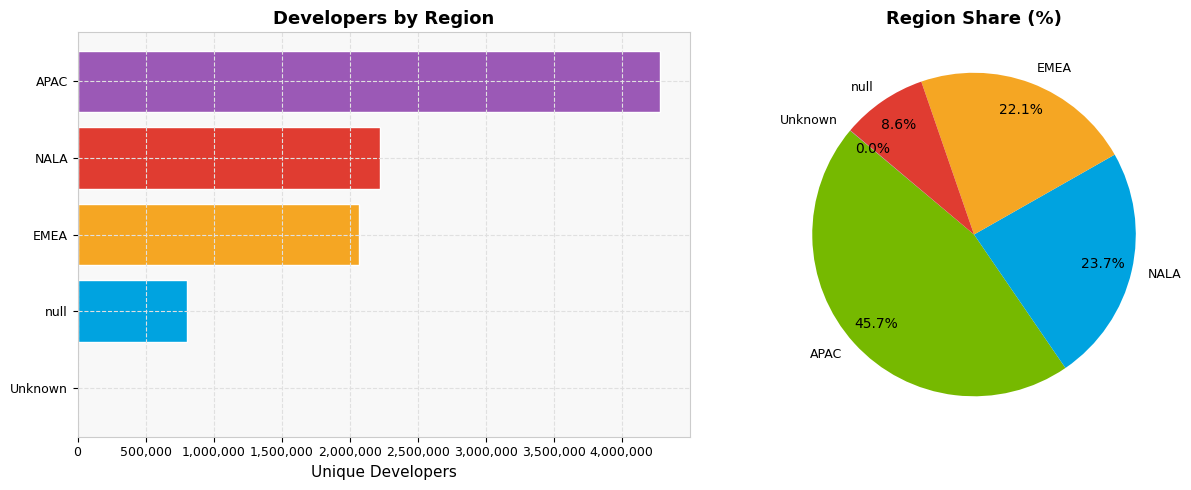

,region,developers,pct
0,APAC,4284392,45.67
1,NALA,2220135,23.67
2,EMEA,2070011,22.06
3,null,804111,8.57
4,Unknown,2841,0.03


In [5]:
# ── region breakdown ─────────────────────────────────────────────────────────
region_df = q(f"""
SELECT
    COALESCE(NULLIF(TRIM(region), ''), 'Unknown') AS region,
    COUNT(DISTINCT developer_id)                  AS developers,
    ROUND(100.0 * COUNT(DISTINCT developer_id)
          / SUM(COUNT(DISTINCT developer_id)) OVER (), 2) AS pct
FROM {CONTACT_TABLE}
GROUP BY 1
ORDER BY developers DESC
""", CONTACT_TABLE=CONTACT_TABLE)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# bar chart
axes[0].barh(region_df["region"][::-1], region_df["developers"][::-1],
             color=PALETTE[:len(region_df)], edgecolor="white")
axes[0].set_title("Developers by Region", fontweight="bold")
axes[0].set_xlabel("Unique Developers")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# pie chart
axes[1].pie(region_df["developers"], labels=region_df["region"],
            autopct="%1.1f%%", colors=PALETTE[:len(region_df)],
            startangle=140, pctdistance=0.82)
axes[1].set_title("Region Share (%)", fontweight="bold")

plt.tight_layout()
plt.show()
display(region_df)

In [6]:
# ── sub-region breakdown ──────────────────────────────────────────────────────
sub_region_df = q(f"""
SELECT
    COALESCE(NULLIF(TRIM(region), ''), 'Unknown')      AS region,
    COALESCE(NULLIF(TRIM(sub_region), ''), 'Unknown')  AS sub_region,
    COUNT(DISTINCT developer_id)                       AS developers
FROM {CONTACT_TABLE}
GROUP BY 1, 2
ORDER BY region, developers DESC
""", CONTACT_TABLE=CONTACT_TABLE)

display(sub_region_df)

,region,sub_region,developers
0,APAC,China,1778896
1,APAC,India,1111879
2,APAC,ROAP,581691
3,APAC,South Korea,305752
4,APAC,Japan,292502
5,APAC,Taiwan,213672
6,EMEA,Europe,1632036
7,EMEA,Africa,236577
8,EMEA,Middle East,129206
9,EMEA,Israel,72192


In [7]:
# ── zone and territory ────────────────────────────────────────────────────────
show("Developers by zone", f"""
SELECT
    COALESCE(NULLIF(TRIM(zone), ''), 'Unknown') AS zone,
    COUNT(DISTINCT developer_id) AS developers,
    ROUND(100.0 * COUNT(DISTINCT developer_id)
          / SUM(COUNT(DISTINCT developer_id)) OVER (), 2) AS pct
FROM {CONTACT_TABLE}
GROUP BY 1
ORDER BY developers DESC
""", CONTACT_TABLE=CONTACT_TABLE)

show("Top 20 territories", f"""
SELECT
    COALESCE(NULLIF(TRIM(territory), ''), 'Unknown') AS territory,
    COUNT(DISTINCT developer_id) AS developers
FROM {CONTACT_TABLE}
GROUP BY 1
ORDER BY developers DESC
LIMIT 20
""", CONTACT_TABLE=CONTACT_TABLE)


────────────────────────────────────────────────────────────
  Developers by zone
────────────────────────────────────────────────────────────


,zone,developers,pct
0,US & Canada,1847414,19.69
1,China,1778896,18.96
2,India,1111879,11.85
3,Western Europe,974818,10.39
4,null,804111,8.57
5,SEA,372441,3.97
6,LatAm,355049,3.78
7,South Korea,305752,3.26
8,Japan,292502,3.12
9,Eastern Europe,241562,2.57



────────────────────────────────────────────────────────────
  Top 20 territories
────────────────────────────────────────────────────────────


,territory,developers
0,null,5417811
1,SOUTH ASIA,1205275
2,LA,370959
3,UK_NORDICS,367236
4,Unknown,318519
5,DACH,299891
6,FRANCE_BENELUX,240859
7,MIDDLE EAST,174872
8,ITALY_GREECE_ISRAEL,167909
9,AFRICA,167687


,territory,developers
0,null,5417811
1,SOUTH ASIA,1205275
2,LA,370959
3,UK_NORDICS,367236
4,Unknown,318519
5,DACH,299891
6,FRANCE_BENELUX,240859
7,MIDDLE EAST,174872
8,ITALY_GREECE_ISRAEL,167909
9,AFRICA,167687


## 4. Industry & Vertical Segmentation

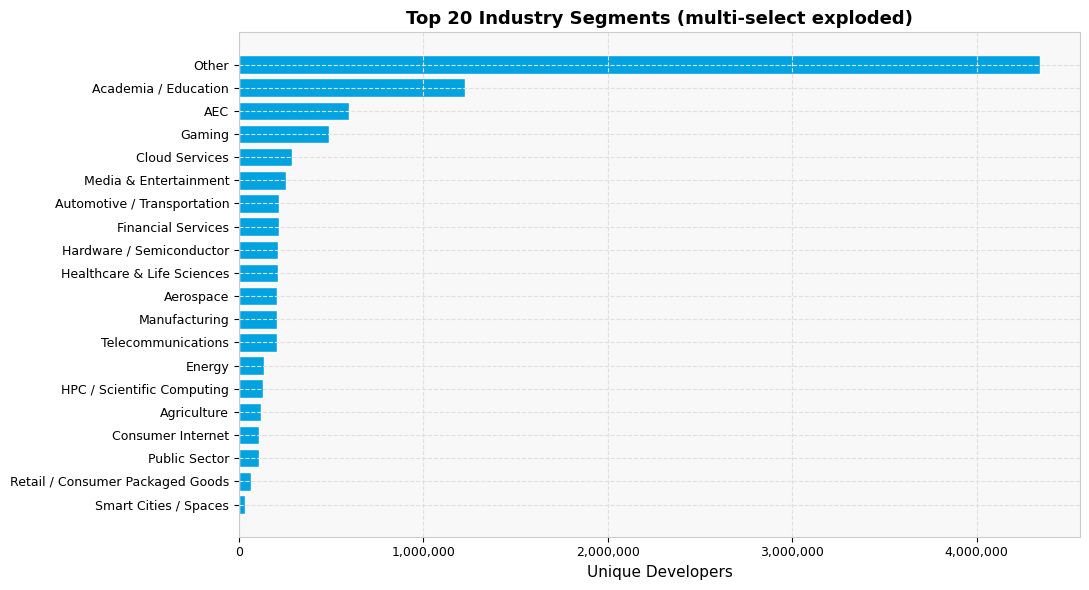

,segment,developers,pct_of_total
0,Other,4342653,46.29
1,Academia / Education,1224186,13.05
2,AEC,594797,6.34
3,Gaming,488951,5.21
4,Cloud Services,285473,3.04
5,Media & Entertainment,256978,2.74
6,Automotive / Transportation,217860,2.32
7,Financial Services,217183,2.32
8,Hardware / Semiconductor,212841,2.27
9,Healthcare & Life Sciences,210352,2.24


In [8]:
# ── industry segment vertical ─────────────────────────────────────────────────
# Note: this field may be pipe-delimited multi-value; we explode it.
industry_df = q(f"""
WITH exploded AS (
    SELECT
        developer_id,
        TRIM(segment) AS segment
    FROM {CONTACT_TABLE},
         UNNEST(STRING_SPLIT(
             COALESCE(NULLIF(TRIM(industry_segment_vertical), ''), 'Unknown'),
             ';'
         )) AS t(segment)
)
SELECT
    segment,
    COUNT(DISTINCT developer_id) AS developers,
    ROUND(100.0 * COUNT(DISTINCT developer_id)
          / (SELECT COUNT(DISTINCT developer_id) FROM {CONTACT_TABLE}), 2) AS pct_of_total
FROM exploded
WHERE TRIM(segment) <> ''
GROUP BY 1
ORDER BY developers DESC
LIMIT 20
""", CONTACT_TABLE=CONTACT_TABLE)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(industry_df["segment"][::-1], industry_df["developers"][::-1],
        color=PALETTE[1], edgecolor="white")
ax.set_title("Top 20 Industry Segments (multi-select exploded)", fontweight="bold")
ax.set_xlabel("Unique Developers")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()
display(industry_df)

In [9]:
# ── sub-industry segment vertical ─────────────────────────────────────────────
show("Top 20 sub-industry segments", f"""
WITH exploded AS (
    SELECT
        developer_id,
        TRIM(seg) AS sub_segment
    FROM {CONTACT_TABLE},
         UNNEST(STRING_SPLIT(
             COALESCE(NULLIF(TRIM(sub_industry_segment_vertical), ''), 'Unknown'),
             ';'
         )) AS t(seg)
)
SELECT
    sub_segment,
    COUNT(DISTINCT developer_id) AS developers
FROM exploded
WHERE TRIM(sub_segment) <> ''
GROUP BY 1
ORDER BY developers DESC
LIMIT 20
""", CONTACT_TABLE=CONTACT_TABLE)


────────────────────────────────────────────────────────────
  Top 20 sub-industry segments
────────────────────────────────────────────────────────────


,sub_segment,developers
0,null,8568121
1,Gaming,448636
2,Unknown,364733


,sub_segment,developers
0,null,8568121
1,Gaming,448636
2,Unknown,364733


## 5. Development Areas & Fields of Interest

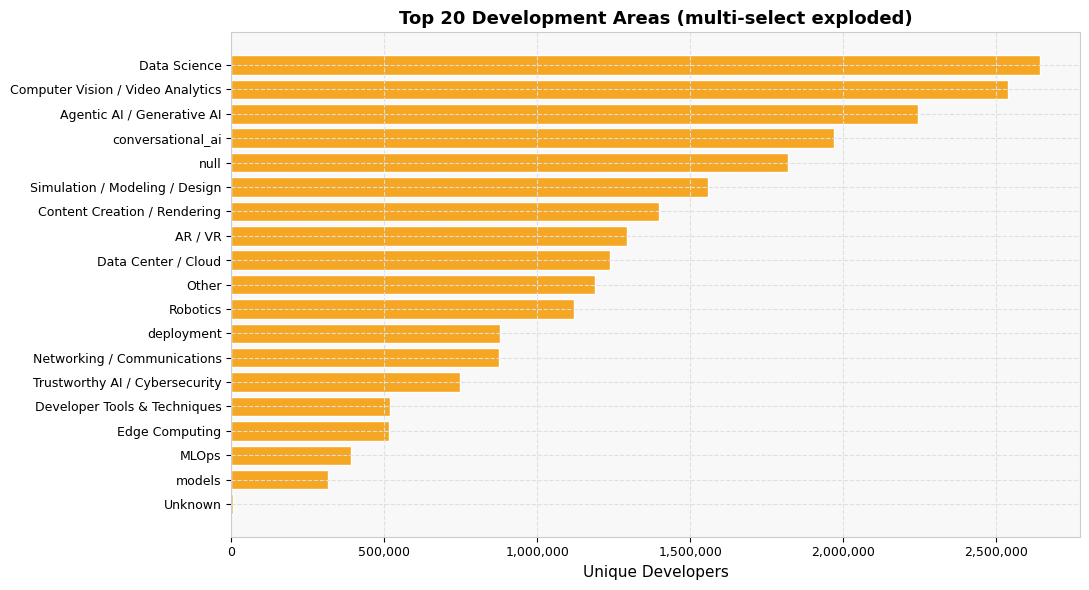

,development_area,developers,pct_of_total
0,Data Science,2642299,28.17
1,Computer Vision / Video Analytics,2540341,27.08
2,Agentic AI / Generative AI,2244773,23.93
3,conversational_ai,1970164,21.00
4,null,1819265,19.39
5,Simulation / Modeling / Design,1557268,16.60
6,Content Creation / Rendering,1399898,14.92
7,AR / VR,1294014,13.79
8,Data Center / Cloud,1238709,13.20
9,Other,1187902,12.66


In [10]:
# ── development areas ────────────────────────────────────────────────────────
dev_areas_df = q(f"""
WITH exploded AS (
    SELECT
        developer_id,
        TRIM(area) AS development_area
    FROM {CONTACT_TABLE},
         UNNEST(STRING_SPLIT(
             COALESCE(NULLIF(TRIM(development_areas), ''), 'Unknown'),
             ';'
         )) AS t(area)
)
SELECT
    development_area,
    COUNT(DISTINCT developer_id) AS developers,
    ROUND(100.0 * COUNT(DISTINCT developer_id)
          / (SELECT COUNT(DISTINCT developer_id) FROM {CONTACT_TABLE}), 2) AS pct_of_total
FROM exploded
WHERE TRIM(development_area) <> ''
GROUP BY 1
ORDER BY developers DESC
LIMIT 20
""", CONTACT_TABLE=CONTACT_TABLE)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(dev_areas_df["development_area"][::-1], dev_areas_df["developers"][::-1],
        color=PALETTE[2], edgecolor="white")
ax.set_title("Top 20 Development Areas (multi-select exploded)", fontweight="bold")
ax.set_xlabel("Unique Developers")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()
display(dev_areas_df)

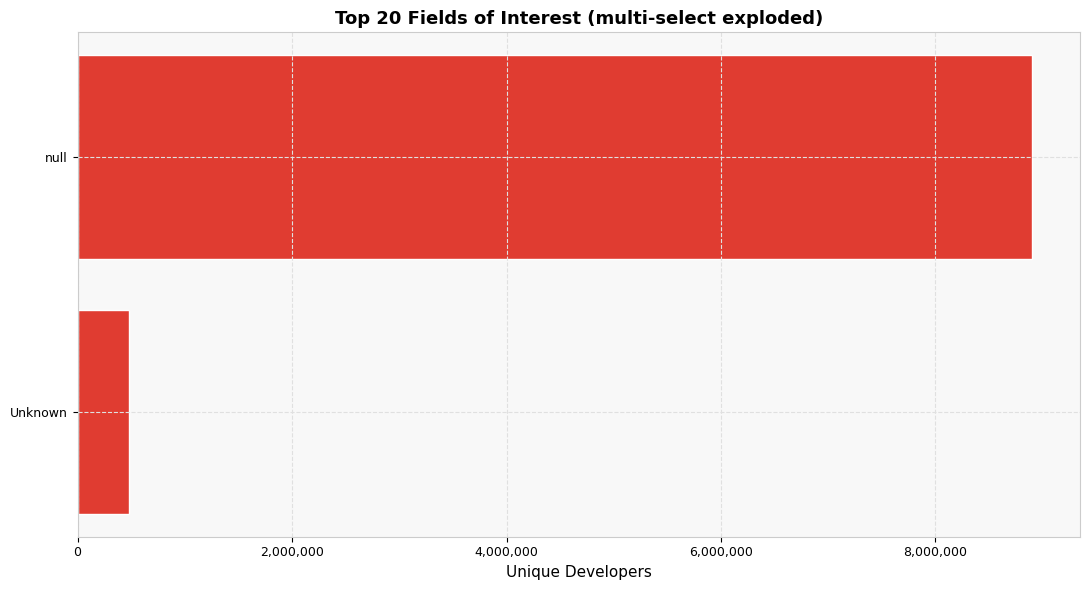

,field_of_interest,developers,pct_of_total
0,null,8903197,94.90
1,Unknown,478293,5.10


In [11]:
# ── fields of interest ────────────────────────────────────────────────────────
foi_df = q(f"""
WITH exploded AS (
    SELECT
        developer_id,
        TRIM(foi) AS field_of_interest
    FROM {CONTACT_TABLE},
         UNNEST(STRING_SPLIT(
             COALESCE(NULLIF(TRIM(fields_of_interest), ''), 'Unknown'),
             ';'
         )) AS t(foi)
)
SELECT
    field_of_interest,
    COUNT(DISTINCT developer_id) AS developers,
    ROUND(100.0 * COUNT(DISTINCT developer_id)
          / (SELECT COUNT(DISTINCT developer_id) FROM {CONTACT_TABLE}), 2) AS pct_of_total
FROM exploded
WHERE TRIM(field_of_interest) <> ''
GROUP BY 1
ORDER BY developers DESC
LIMIT 20
""", CONTACT_TABLE=CONTACT_TABLE)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(foi_df["field_of_interest"][::-1], foi_df["developers"][::-1],
        color=PALETTE[3], edgecolor="white")
ax.set_title("Top 20 Fields of Interest (multi-select exploded)", fontweight="bold")
ax.set_xlabel("Unique Developers")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()
display(foi_df)

In [12]:
# ── co-occurrence: development areas × fields of interest (top pairs) ─────────
show("Top 20 development area × field-of-interest co-occurrences", f"""
WITH da AS (
    SELECT developer_id, TRIM(area) AS development_area
    FROM {CONTACT_TABLE},
         UNNEST(STRING_SPLIT(COALESCE(NULLIF(TRIM(development_areas),''),'Unknown'), ';')) AS t(area)
    WHERE TRIM(area) <> ''
),
foi AS (
    SELECT developer_id, TRIM(foi) AS field_of_interest
    FROM {CONTACT_TABLE},
         UNNEST(STRING_SPLIT(COALESCE(NULLIF(TRIM(fields_of_interest),''),'Unknown'), ';')) AS t(foi)
    WHERE TRIM(foi) <> ''
)
SELECT
    da.development_area,
    foi.field_of_interest,
    COUNT(DISTINCT da.developer_id) AS developers
FROM da
JOIN foi ON da.developer_id = foi.developer_id
GROUP BY 1, 2
ORDER BY developers DESC
LIMIT 20
""", CONTACT_TABLE=CONTACT_TABLE)


────────────────────────────────────────────────────────────
  Top 20 development area × field-of-interest co-occurrences
────────────────────────────────────────────────────────────


,development_area,field_of_interest,developers
0,Data Science,null,2390678
1,Computer Vision / Video Analytics,null,2263442
2,Agentic AI / Generative AI,null,2200935
3,null,null,1819265
4,conversational_ai,null,1746760
5,Simulation / Modeling / Design,null,1383236
6,Content Creation / Rendering,null,1281474
7,AR / VR,null,1214156
8,Other,null,1153438
9,Data Center / Cloud,null,1104861


,development_area,field_of_interest,developers
0,Data Science,null,2390678
1,Computer Vision / Video Analytics,null,2263442
2,Agentic AI / Generative AI,null,2200935
3,null,null,1819265
4,conversational_ai,null,1746760
5,Simulation / Modeling / Design,null,1383236
6,Content Creation / Rendering,null,1281474
7,AR / VR,null,1214156
8,Other,null,1153438
9,Data Center / Cloud,null,1104861


## 6. Account Profile

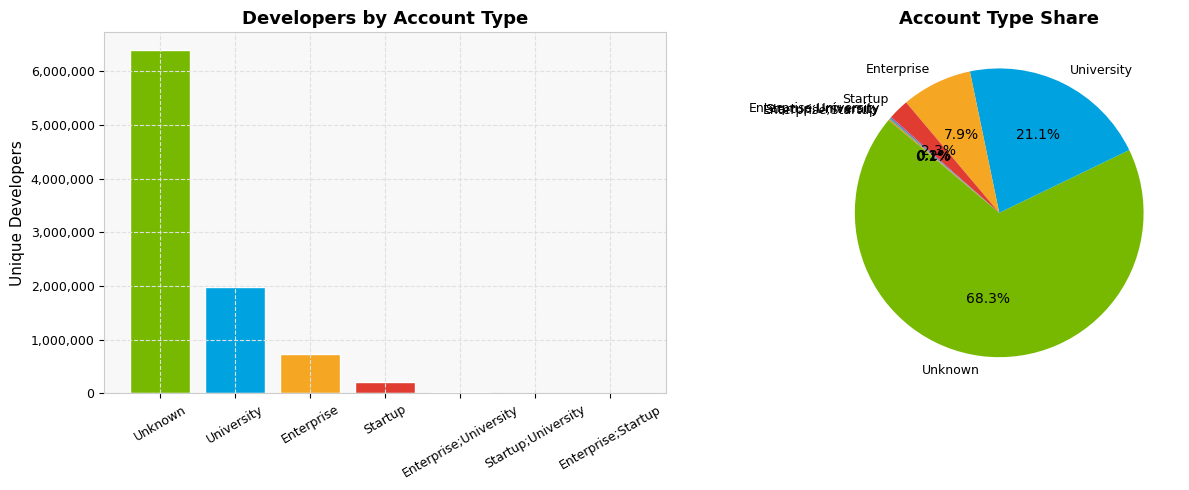

,account_type,developers,pct
0,Unknown,6404129,68.26
1,University,1980017,21.11
2,Enterprise,740459,7.89
3,Startup,215987,2.30
4,Enterprise;University,16654,0.18
5,Startup;University,12856,0.14
6,Enterprise;Startup,11388,0.12


In [13]:
# ── account type ──────────────────────────────────────────────────────────────
acct_type_df = q(f"""
SELECT
    COALESCE(NULLIF(TRIM(account_type), ''), 'Unknown') AS account_type,
    COUNT(DISTINCT developer_id) AS developers,
    ROUND(100.0 * COUNT(DISTINCT developer_id)
          / SUM(COUNT(DISTINCT developer_id)) OVER (), 2) AS pct
FROM {CONTACT_TABLE}
GROUP BY 1
ORDER BY developers DESC
""", CONTACT_TABLE=CONTACT_TABLE)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(acct_type_df["account_type"], acct_type_df["developers"],
            color=PALETTE[:len(acct_type_df)], edgecolor="white")
axes[0].set_title("Developers by Account Type", fontweight="bold")
axes[0].set_ylabel("Unique Developers")
axes[0].tick_params(axis="x", rotation=30)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

axes[1].pie(acct_type_df["developers"], labels=acct_type_df["account_type"],
            autopct="%1.1f%%", colors=PALETTE[:len(acct_type_df)], startangle=140)
axes[1].set_title("Account Type Share", fontweight="bold")
plt.tight_layout()
plt.show()
display(acct_type_df)

In [14]:
# ── account source ────────────────────────────────────────────────────────────
show("Developers by account source", f"""
SELECT
    COALESCE(NULLIF(TRIM(account_source), ''), 'Unknown') AS account_source,
    COUNT(DISTINCT developer_id) AS developers,
    ROUND(100.0 * COUNT(DISTINCT developer_id)
          / SUM(COUNT(DISTINCT developer_id)) OVER (), 2) AS pct
FROM {CONTACT_TABLE}
GROUP BY 1
ORDER BY developers DESC
""", CONTACT_TABLE=CONTACT_TABLE)


────────────────────────────────────────────────────────────
  Developers by account source
────────────────────────────────────────────────────────────


,account_source,developers,pct
0,null,3132203,33.39
1,Manual,2495695,26.60
2,WWFO,411861,4.39
3,University: India,266222,2.84
4,University: China;WWFO,249381,2.66
...,...,...,...
480,Leadspace;IPM,6,0.00
481,Connect;ISV;Top AI StartUps,6,0.00
482,Manual;IPM,6,0.00
483,Inception;OOB,5,0.00


,account_source,developers,pct
0,null,3132203,33.39
1,Manual,2495695,26.60
2,WWFO,411861,4.39
3,University: India,266222,2.84
4,University: China;WWFO,249381,2.66
...,...,...,...
480,Leadspace;IPM,6,0.00
481,Connect;ISV;Top AI StartUps,6,0.00
482,Manual;IPM,6,0.00
483,Inception;OOB,5,0.00


In [15]:
# ── account industry segment ──────────────────────────────────────────────────
show("Top 20 account industry segments", f"""
SELECT
    COALESCE(NULLIF(TRIM(account_industry_segment), ''), 'Unknown') AS account_industry_segment,
    COUNT(DISTINCT developer_id) AS developers,
    ROUND(100.0 * COUNT(DISTINCT developer_id)
          / SUM(COUNT(DISTINCT developer_id)) OVER (), 2) AS pct
FROM {CONTACT_TABLE}
GROUP BY 1
ORDER BY developers DESC
LIMIT 20
""", CONTACT_TABLE=CONTACT_TABLE)


────────────────────────────────────────────────────────────
  Top 20 account industry segments
────────────────────────────────────────────────────────────


,account_industry_segment,developers,pct
0,null,8903197,94.90
1,Unknown,478293,5.10


,account_industry_segment,developers,pct
0,null,8903197,94.90
1,Unknown,478293,5.10


## 7. Program Enrollment & Engagement Over Time

In [16]:
# ── program application source ────────────────────────────────────────────────
show("Developers by program application source", f"""
SELECT
    COALESCE(NULLIF(TRIM(program_application_source), ''), 'Unknown') AS program_application_source,
    COUNT(DISTINCT developer_id) AS developers,
    ROUND(100.0 * COUNT(DISTINCT developer_id)
          / SUM(COUNT(DISTINCT developer_id)) OVER (), 2) AS pct
FROM {CONTACT_TABLE}
GROUP BY 1
ORDER BY developers DESC
""", CONTACT_TABLE=CONTACT_TABLE)


────────────────────────────────────────────────────────────
  Developers by program application source
────────────────────────────────────────────────────────────


,program_application_source,developers,pct
0,null,4006295,42.70
1,devzone,2806574,29.92
2,dli,1004037,10.70
3,gtc,448297,4.78
4,Unknown,446092,4.76
5,api_catalog,391786,4.18
6,GTC Fall 2022,107396,1.14
7,GTC Spring 2022,89807,0.96
8,nod,46301,0.49
9,brev,10869,0.12


,program_application_source,developers,pct
0,null,4006295,42.70
1,devzone,2806574,29.92
2,dli,1004037,10.70
3,gtc,448297,4.78
4,Unknown,446092,4.76
5,api_catalog,391786,4.18
6,GTC Fall 2022,107396,1.14
7,GTC Spring 2022,89807,0.96
8,nod,46301,0.49
9,brev,10869,0.12


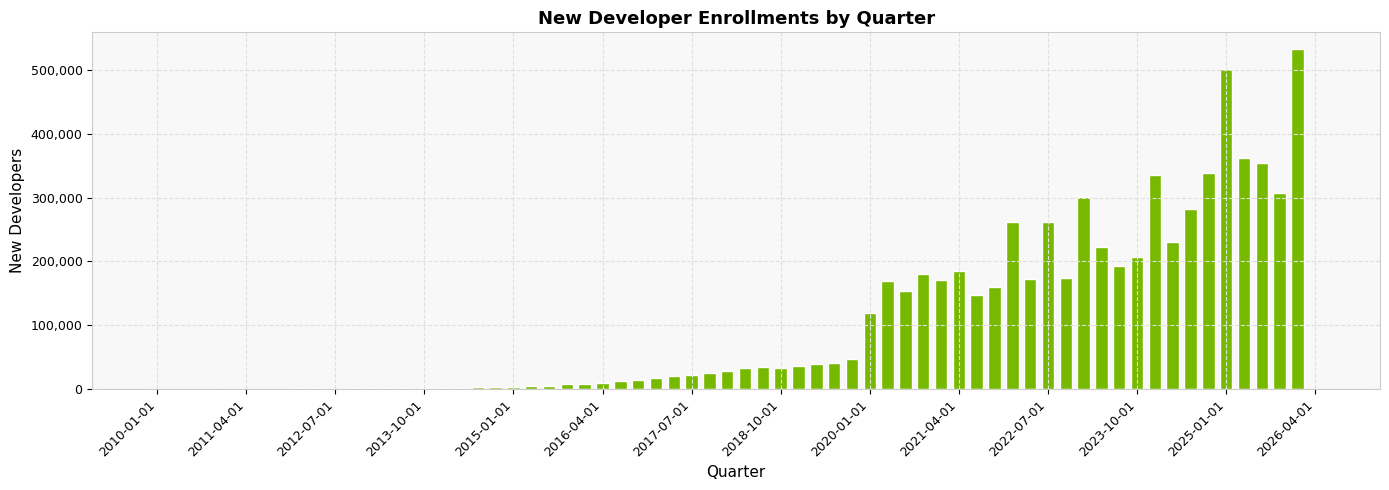

,enroll_quarter,new_developers
54,2023-07-01,193427
55,2023-10-01,206451
56,2024-01-01,336014
57,2024-04-01,230836
58,2024-07-01,281381
59,2024-10-01,338558
60,2025-01-01,501546
61,2025-04-01,362269
62,2025-07-01,354084
63,2025-10-01,306332


In [17]:
# ── new enrollments by quarter ────────────────────────────────────────────────
enroll_df = q(f"""
SELECT
    DATE_TRUNC('quarter', first_program_application_date)::DATE AS enroll_quarter,
    COUNT(DISTINCT developer_id) AS new_developers
FROM {CONTACT_TABLE}
WHERE first_program_application_date IS NOT NULL
  AND first_program_application_date > '2010-01-01'
  AND first_program_application_date <= CURRENT_DATE
GROUP BY 1
ORDER BY 1
""", CONTACT_TABLE=CONTACT_TABLE)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(enroll_df["enroll_quarter"].astype(str), enroll_df["new_developers"],
       color=NVIDIA_GREEN, edgecolor="white", width=0.7)
ax.set_title("New Developer Enrollments by Quarter", fontweight="bold")
ax.set_xlabel("Quarter")
ax.set_ylabel("New Developers")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
tick_step = max(1, len(enroll_df) // 12)
ax.set_xticks(range(0, len(enroll_df), tick_step))
ax.set_xticklabels(enroll_df["enroll_quarter"].astype(str).iloc[::tick_step],
                   rotation=45, ha="right")
plt.tight_layout()
plt.show()
display(enroll_df.tail(12))

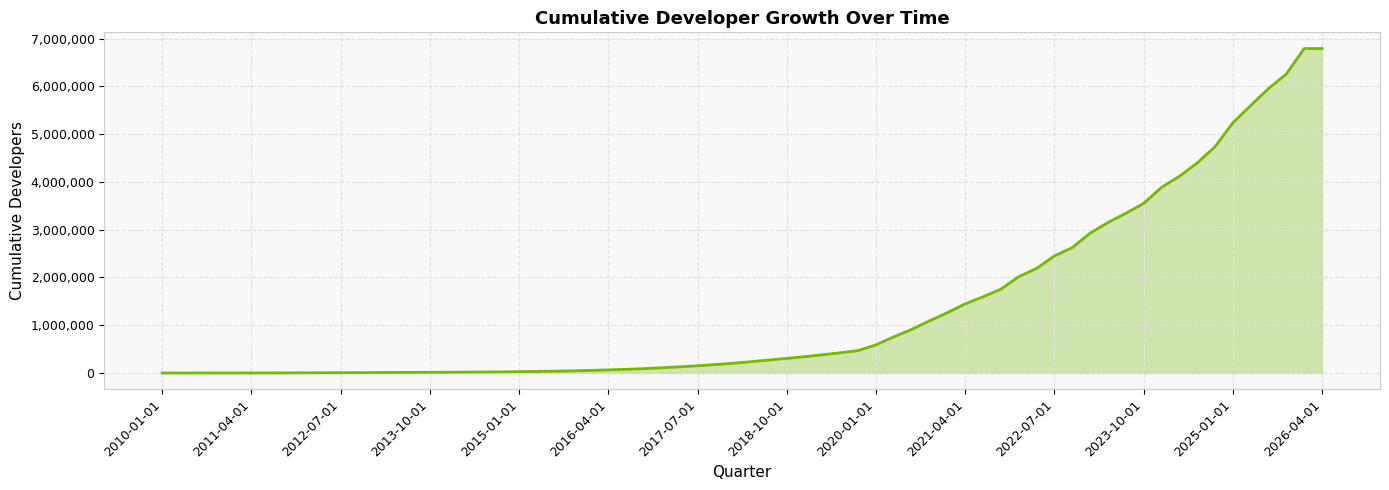

In [18]:
# ── cumulative developer growth ───────────────────────────────────────────────
cumulative_df = q(f"""
SELECT
    enroll_quarter,
    new_developers,
    SUM(new_developers) OVER (ORDER BY enroll_quarter) AS cumulative_developers
FROM (
    SELECT
        DATE_TRUNC('quarter', first_program_application_date)::DATE AS enroll_quarter,
        COUNT(DISTINCT developer_id) AS new_developers
    FROM {CONTACT_TABLE}
    WHERE first_program_application_date IS NOT NULL
      AND first_program_application_date > '2010-01-01'
      AND first_program_application_date <= CURRENT_DATE
    GROUP BY 1
) t
ORDER BY enroll_quarter
""", CONTACT_TABLE=CONTACT_TABLE)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(cumulative_df["enroll_quarter"].astype(str),
                cumulative_df["cumulative_developers"],
                color=NVIDIA_GREEN, alpha=0.3)
ax.plot(cumulative_df["enroll_quarter"].astype(str),
        cumulative_df["cumulative_developers"],
        color=NVIDIA_GREEN, linewidth=2)
ax.set_title("Cumulative Developer Growth Over Time", fontweight="bold")
ax.set_xlabel("Quarter")
ax.set_ylabel("Cumulative Developers")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
tick_step = max(1, len(cumulative_df) // 12)
ax.set_xticks(range(0, len(cumulative_df), tick_step))
ax.set_xticklabels(cumulative_df["enroll_quarter"].astype(str).iloc[::tick_step],
                   rotation=45, ha="right")
plt.tight_layout()
plt.show()

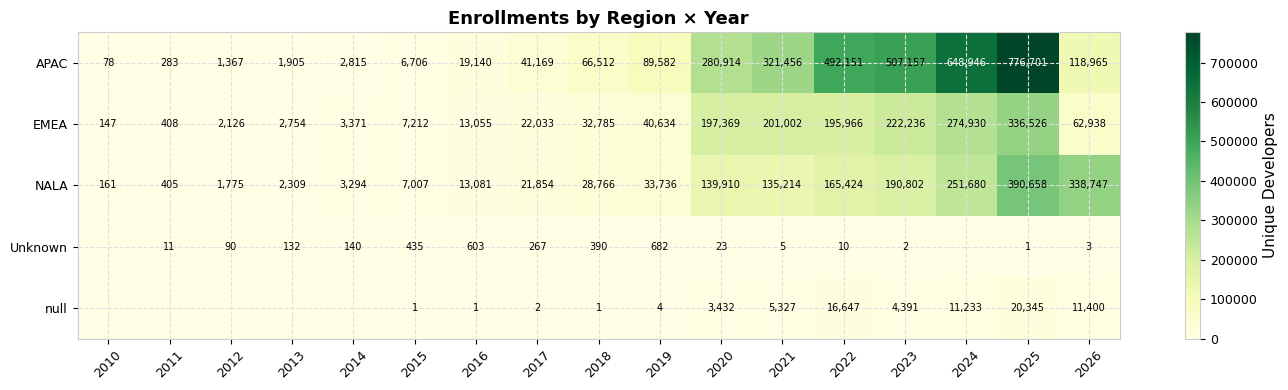

In [19]:
# ── enrollment by region × year (heatmap) ─────────────────────────────────────
region_year_df = q(f"""
SELECT
    COALESCE(NULLIF(TRIM(region), ''), 'Unknown')                   AS region,
    YEAR(first_program_application_date)                            AS enroll_year,
    COUNT(DISTINCT developer_id)                                    AS developers
FROM {CONTACT_TABLE}
WHERE first_program_application_date IS NOT NULL
  AND first_program_application_date > '2010-01-01'
  AND first_program_application_date <= CURRENT_DATE
GROUP BY 1, 2
ORDER BY 1, 2
""", CONTACT_TABLE=CONTACT_TABLE)

pivot = region_year_df.pivot(index="region", columns="enroll_year", values="developers").fillna(0)

fig, ax = plt.subplots(figsize=(14, max(4, len(pivot) * 0.6)))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlGn")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns.astype(int), rotation=45)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = int(pivot.values[i, j])
        if val > 0:
            ax.text(j, i, f"{val:,}", ha="center", va="center", fontsize=7,
                    color="black" if val < pivot.values.max() * 0.7 else "white")
plt.colorbar(im, ax=ax, label="Unique Developers")
ax.set_title("Enrollments by Region × Year", fontweight="bold")
plt.tight_layout()
plt.show()

## 8. WWFO Segmentation

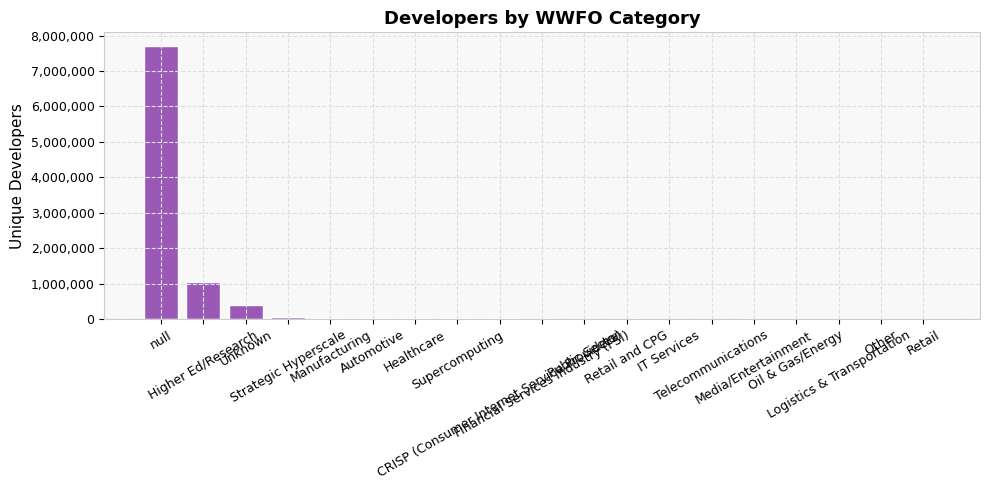

,wwfo_category,developers,pct
0,null,7707466,82.16
1,Higher Ed/Research,1059005,11.29
2,Unknown,397162,4.23
3,Strategic Hyperscale,42925,0.46
4,Manufacturing,38125,0.41
5,Automotive,34371,0.37
6,Healthcare,26609,0.28
7,Supercomputing,18224,0.19
8,CRISP (Consumer Internet Service Providers),16972,0.18
9,Financial Services Industry (FSI),13344,0.14


In [20]:
# ── wwfo category ─────────────────────────────────────────────────────────────
wwfo_df = q(f"""
SELECT
    COALESCE(NULLIF(TRIM(wwfo_category), ''), 'Unknown') AS wwfo_category,
    COUNT(DISTINCT developer_id) AS developers,
    ROUND(100.0 * COUNT(DISTINCT developer_id)
          / SUM(COUNT(DISTINCT developer_id)) OVER (), 2) AS pct
FROM {CONTACT_TABLE}
GROUP BY 1
ORDER BY developers DESC
""", CONTACT_TABLE=CONTACT_TABLE)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(wwfo_df["wwfo_category"], wwfo_df["developers"],
       color=PALETTE[4], edgecolor="white")
ax.set_title("Developers by WWFO Category", fontweight="bold")
ax.set_ylabel("Unique Developers")
ax.tick_params(axis="x", rotation=30)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()
display(wwfo_df)

In [21]:
# ── wwfo category × region cross-tab ─────────────────────────────────────────
wwfo_region = q(f"""
SELECT
    COALESCE(NULLIF(TRIM(wwfo_category), ''), 'Unknown') AS wwfo_category,
    COALESCE(NULLIF(TRIM(region), ''), 'Unknown')        AS region,
    COUNT(DISTINCT developer_id)                         AS developers
FROM {CONTACT_TABLE}
GROUP BY 1, 2
ORDER BY wwfo_category, developers DESC
""", CONTACT_TABLE=CONTACT_TABLE)

pivot_wr = wwfo_region.pivot(index="wwfo_category", columns="region", values="developers").fillna(0)
display(pivot_wr.style.background_gradient(cmap="Greens", axis=1).format("{:,.0f}"))

region,APAC,EMEA,NALA,Unknown,null
wwfo_category,,,,,
Automotive,"15,229","10,050","8,778",3,311
CRISP (Consumer Internet Service Providers),"11,228","1,854","3,800",0,90
Financial Services Industry (FSI),"3,099","3,222","6,872",2,149
Healthcare,"6,459","8,091","11,839",9,211
Higher Ed/Research,"675,086","164,908","216,333",102,"2,576"
IT Services,"2,330",961,"2,477",2,50
Logistics & Transportation,185,44,25,0,0
Manufacturing,"26,448","5,397","5,958",3,319
Media/Entertainment,344,113,107,0,4


## 9. Cross-Demographic Profiles

In [22]:
# ── top 15 country × industry segment combinations ────────────────────────────
show("Top 15 country × industry segment combinations", f"""
WITH exploded AS (
    SELECT
        developer_id,
        COALESCE(NULLIF(TRIM(country), ''), 'Unknown') AS country,
        TRIM(seg) AS segment
    FROM {CONTACT_TABLE},
         UNNEST(STRING_SPLIT(
             COALESCE(NULLIF(TRIM(industry_segment_vertical), ''), 'Unknown'), ';'
         )) AS t(seg)
    WHERE TRIM(seg) <> ''
)
SELECT
    country,
    segment,
    COUNT(DISTINCT developer_id) AS developers
FROM exploded
GROUP BY 1, 2
ORDER BY developers DESC
LIMIT 15
""", CONTACT_TABLE=CONTACT_TABLE)


────────────────────────────────────────────────────────────
  Top 15 country × industry segment combinations
────────────────────────────────────────────────────────────


,country,segment,developers
0,United States,Other,884368
1,null,Other,790494
2,China,Other,651565
3,India,Other,417968
4,China,Academia / Education,308939
5,India,Academia / Education,189336
6,India,AEC,177636
7,United States,Academia / Education,136200
8,"Korea, Republic of",Other,122489
9,Japan,Other,121070


,country,segment,developers
0,United States,Other,884368
1,null,Other,790494
2,China,Other,651565
3,India,Other,417968
4,China,Academia / Education,308939
5,India,Academia / Education,189336
6,India,AEC,177636
7,United States,Academia / Education,136200
8,"Korea, Republic of",Other,122489
9,Japan,Other,121070


In [23]:
# ── account type × region ─────────────────────────────────────────────────────
at_region = q(f"""
SELECT
    COALESCE(NULLIF(TRIM(account_type), ''), 'Unknown') AS account_type,
    COALESCE(NULLIF(TRIM(region), ''), 'Unknown')       AS region,
    COUNT(DISTINCT developer_id)                        AS developers
FROM {CONTACT_TABLE}
GROUP BY 1, 2
ORDER BY account_type, developers DESC
""", CONTACT_TABLE=CONTACT_TABLE)

pivot_at = at_region.pivot(index="account_type", columns="region", values="developers").fillna(0)
display(pivot_at.style.background_gradient(cmap="Blues", axis=1).format("{:,.0f}"))

region,APAC,EMEA,NALA,Unknown,null
account_type,,,,,
Enterprise,"333,532","151,416","249,163",296,"6,052"
Enterprise;Startup,"4,756","3,251","3,258",1,122
Enterprise;University,"9,312","6,916",411,1,14
Startup,"97,276","61,444","56,236",35,996
Startup;University,"2,001","7,692","3,130",1,32
University,"1,447,557","335,875","192,839",208,"3,538"
Unknown,"2,389,958","1,503,417","1,715,098","2,299","793,357"


## 10. Missingness Audit

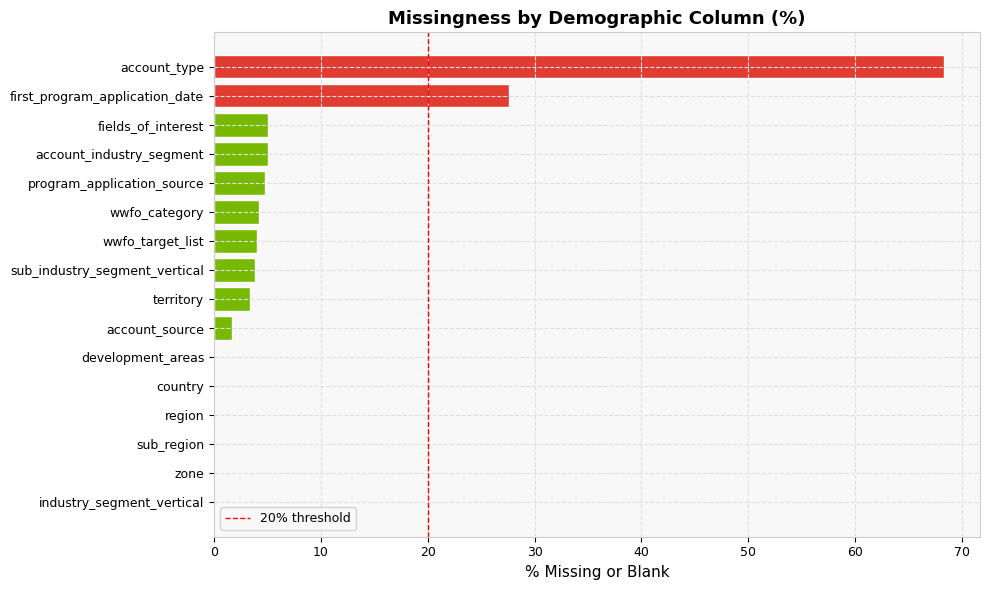

,column,missing_rows,missing_pct
9,account_type,"6,404,129.00",68.26
15,first_program_application_date,"2,589,151.00",27.60
8,fields_of_interest,"478,293.00",5.10
11,account_industry_segment,"478,293.00",5.10
12,program_application_source,"446,092.00",4.76
13,wwfo_category,"397,162.00",4.23
14,wwfo_target_list,"375,304.00",4.00
6,sub_industry_segment_vertical,"364,733.00",3.89
4,territory,"318,519.00",3.40
10,account_source,"159,357.00",1.70


In [24]:
# ── null / blank rates for all key demographic columns ─────────────────────────
demographic_cols = [
    "country", "region", "sub_region", "zone", "territory",
    "industry_segment_vertical", "sub_industry_segment_vertical",
    "development_areas", "fields_of_interest",
    "account_type", "account_source", "account_industry_segment",
    "program_application_source", "wwfo_category", "wwfo_target_list",
    "first_program_application_date",
]

# Build a query that counts nulls/blanks for each column
null_checks = ",\n    ".join([
    f"SUM(CASE WHEN {c} IS NULL OR TRIM(CAST({c} AS VARCHAR)) = '' THEN 1 ELSE 0 END) AS {c}_missing"
    for c in demographic_cols
])

miss_df_raw = q(f"""
SELECT
    COUNT(*) AS total_rows,
    {null_checks}
FROM {CONTACT_TABLE}
""", CONTACT_TABLE=CONTACT_TABLE)

total = miss_df_raw["total_rows"].iloc[0]
miss_df = pd.DataFrame({
    "column":      demographic_cols,
    "missing_rows": [miss_df_raw[f"{c}_missing"].iloc[0] for c in demographic_cols],
})
miss_df["missing_pct"] = (miss_df["missing_rows"] / total * 100).round(2)
miss_df = miss_df.sort_values("missing_pct", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#e03c31" if p > 20 else NVIDIA_GREEN for p in miss_df["missing_pct"]]
ax.barh(miss_df["column"][::-1], miss_df["missing_pct"][::-1],
        color=colors[::-1], edgecolor="white")
ax.axvline(20, color="red", linestyle="--", linewidth=1, label="20% threshold")
ax.set_title("Missingness by Demographic Column (%)", fontweight="bold")
ax.set_xlabel("% Missing or Blank")
ax.legend()
plt.tight_layout()
plt.show()
display(miss_df)

In [25]:
# ── close connection ──────────────────────────────────────────────────────────
con.close()
print("Connection closed. EDA complete.")

Connection closed. EDA complete.
